In [1]:
import numpy as np

import batoid
from batoid_rubin import LSSTBuilder
from galsim.zernike import zernikeRotMatrix

from lsst.ts.ofc import OFCData, StateEstimator

import matplotlib.pyplot as plt
from lsst.summit.utils import (
    ConsDbClient, 
    getBandpassSeeingCorrection, 
    getAirmassSeeingCorrection,
    makeDefaultButler
)
import pandas as pd
from lsst.daf.butler import Butler
from lsst.ts.aos.analysis import ofcUtils
from lsst_efd_client import EfdClient
from tqdm import tqdm as tqdm
%matplotlib widget

In [2]:
ofc_data_config_dir_path = '/home/gmegias/notebooks/lsst-ts/ts_config_mttcs/MTAOS/v8/ofc/'
ofc_data = OFCData(
    "lsst", 
    config_dir=ofc_data_config_dir_path
)
corner_rafts = [
    "R00", "R40",  # As they are laid out on the sky at RTP=0
    "R04", "R44",
]
corner_dets = [  # extra-focal
    191, 195, 
    199, 203,
]
corner_detnames = [  # extra-focal
    "R00_SW0", "R04_SW0",
    "R40_SW0", "R44_SW0",
]
field_angles_CCS = [
    ofc_data.sample_points[det] for det in corner_detnames
]

In [3]:
def parse_dof_str(dof_str):
    """Turn '0-4,10-14' into [0,1,2,3,4,10,11,12,13,14] for example...
    """
    dof_str = dof_str.strip()
    use_dof = []
    for part in dof_str.split(","):
        if "-" in part:
            start, end = [int(p) for p in part.split("-")]
            use_dof.extend(range(start, end + 1))
        else:
            use_dof.append(int(part))
    use_dof = np.sort(use_dof)
    return use_dof

In [4]:
def get_state(zk_ccs, rtp, use_dof, nkeep, band):
    ofc_data = OFCData(
        "lsst", 
        config_dir=ofc_data_config_dir_path
    )
    if isinstance(use_dof, str):
        use_dof = parse_dof_str(use_dof)

    new_comp_dof_idx = dict(
        m2HexPos=np.full(5, False, dtype=bool),
        camHexPos=np.full(5, False, dtype=bool),
        M1M3Bend=np.full(20, False, dtype=bool),
        M2Bend=np.full(20, False, dtype=bool),
    )
    for idof in use_dof:
        if idof < 5:
            new_comp_dof_idx["m2HexPos"][idof] = True
        elif 5 <= idof < 10:
            new_comp_dof_idx["camHexPos"][idof-5] = True
        elif 10 <= idof < 30:
            new_comp_dof_idx["M1M3Bend"][idof-10] = True
        elif 30 <= idof < 50:
            new_comp_dof_idx["M2Bend"][idof-30] = True

    ofc_data.comp_dof_idx = new_comp_dof_idx
    ofc_data.controller["truncation_index"] = nkeep
    state_estimator = StateEstimator(ofc_data)
        
    return state_estimator.dof_state(
        band.upper(),
        zk_ccs,
        corner_detnames,
        rtp,
    )

In [100]:
seqs_list = np.arange(247, 280)
day = 20251022


seqs_list = np.arange(36, 91)
day = 20251023

butler = Butler('LSSTCam', instrument='LSSTCam', collections=['LSSTCam/runs/quickLook'])
efd_client = EfdClient('summit_efd')
fetcher = ofcUtils.AOSFetcher(butler, efd_client, config_dir=ofc_data_config_dir_path)
query = f'''
    SELECT 
    e.seq_num AS seq,
    e.band,
    q.physical_rotator_angle,
    visit1.altitude,
    e.obs_end,
    e.obs_start
    FROM
    cdb_lsstcam.visit1 AS visit1,
    cdb_lsstcam.visit1_quicklook AS q,
    cdb_lsstcam.exposure AS e
    WHERE 
    visit1.visit_id = q.visit_id 
    AND visit1.visit_id = e.exposure_id
    AND (e.img_type = 'science' or e.img_type = 'acq') 
    AND (e.seq_num BETWEEN {np.min(seqs_list)} AND {np.max(seqs_list)})
    AND (e.day_obs = {day})
'''
cdb_client = ConsDbClient('http://consdb-pq.consdb:8080/consdb')
cdb_table = cdb_client.query(query).to_pandas()

In [101]:
use_dof = parse_dof_str("5-9")
nkeep = 3

states_array = []
elevations_array = []
rotations_array = []
for seq in tqdm(seqs_list):
    cdb_seq = cdb_table[cdb_table["seq"] == seq]
    zernikes, zernike_array, noll_indices, sensor_names = fetcher.get_zernikes(int(f"{int(day)}{str(seq).zfill(5)}"))
    state = get_state(
        zernike_array,
        rtp=cdb_seq["physical_rotator_angle"].iloc[0],
        use_dof=use_dof,
        nkeep=nkeep,
        band=cdb_seq["band"].iloc[0]
    )

    states_array.append(-state)
    rotations_array.append(round(cdb_seq["physical_rotator_angle"].iloc[0]))
    elevations_array.append(round(cdb_seq["altitude"].iloc[0]))

states_array = np.array(states_array)
elevations_array = np.array(elevations_array)
rotations_array = np.array(rotations_array)

100%|██████████| 55/55 [03:15<00:00,  3.55s/it]


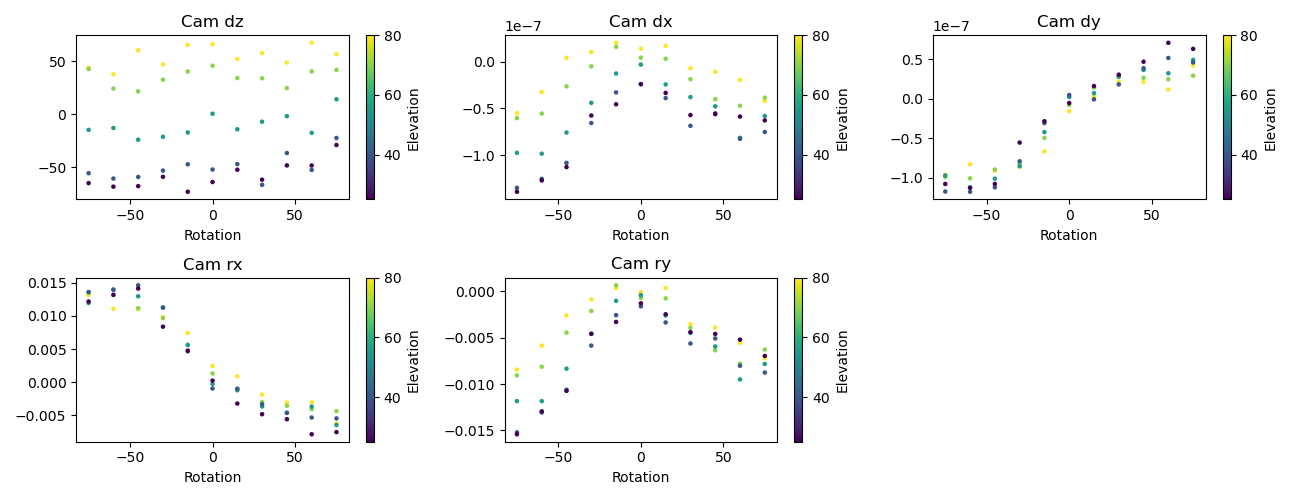

In [102]:
labels = ['Cam dz','Cam dx', 'Cam dy',  'Cam rx', 'Cam ry']
rots = np.linspace(min(rots_by_seq.values), max(rots_by_seq.values), 100)
plt.figure(figsize = (13, 5))
for i, dof in enumerate(use_dof):
    plt.subplot(2, 3, i + 1)
    plt.scatter(rotations_array, -states_array[:, i], c=elevations_array, s=5, label='OFC')
    plt.colorbar(label = 'Elevation')
    plt.xlabel('Rotation')
    plt.title(labels[i])

plt.tight_layout()

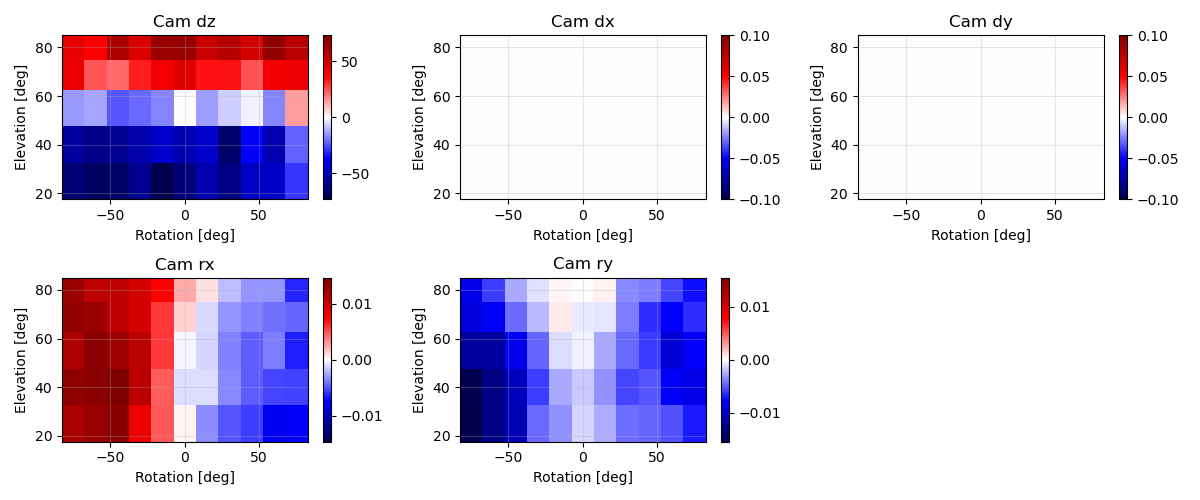

In [103]:
plt.figure(figsize=(12, 5))
for i, dof in enumerate(use_dof):
    ax = plt.subplot(2, 3, i + 1)

    # pivot the data so pcolormesh can use a rectangular grid
    df_plot = pd.DataFrame({
        "rot": rotations_array[:],
        "el": elevations_array[:],
        "val": -states_array[:, i]
    })
    grid = df_plot.pivot(index="el", columns="rot", values="val")

    abs_max = np.nanmax(np.abs(grid.values))
    if i < 3:
        abs_max = max(abs_max, 0.1)  # enforce at least ±0.1 range

    vmin, vmax = -abs_max, abs_max
    surf = ax.pcolormesh(grid.columns, grid.index, grid.values,
                         shading="auto", cmap="seismic",
                        vmin=vmin, vmax=vmax)
    plt.colorbar(surf, ax=ax)
    ax.set_title(labels[i])
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cam dz: [[-5.99086256e+02 -4.70554033e-01 -4.67952745e-03  6.22198935e-05]
 [ 2.75839851e+01  1.74164117e-02  9.49438429e-05 -1.93302750e-06]
 [-3.36717213e-01 -1.54817349e-04 -7.69600461e-07  1.66707689e-08]
 [ 1.35075811e-03  2.42083252e-16 -1.60459804e-18  3.35848604e-16]]
--------------------
Cam dx: [[-1.29956022e+03 -5.44338781e+01  3.36038142e-01  2.52634737e-03
  -9.26523951e-06 -8.46363619e-10]
 [-1.23932021e+00 -8.89047852e-03  4.71481469e-04  6.31217845e-06
  -7.70967718e-08 -8.21527982e-10]
 [ 2.31725581e-02  2.47797283e-04 -4.64816941e-06 -1.06142497e-07
   6.92150005e-10  9.94256760e-12]
 [ 3.90449175e-13 -4.22707497e-07  0.00000000e+00  5.75638706e-11
   0.00000000e+00  0.00000000e+00]]
--------------------
Cam dy: [[ 3.15756793e+03 -3.24738161e+01 -4.90241272e-01  1.86429768e-03
   1.23409336e-05 -7.25389478e-08]
 [-1.93040093e+01 -7.52778333e-02  2.81331618e-04  1.38072365e-05
  -4.30455130e-08 -1.06685853e-09]
 [-1.44611554e-01  5.88338125e-04 -1.63390005e-06 -1.00748

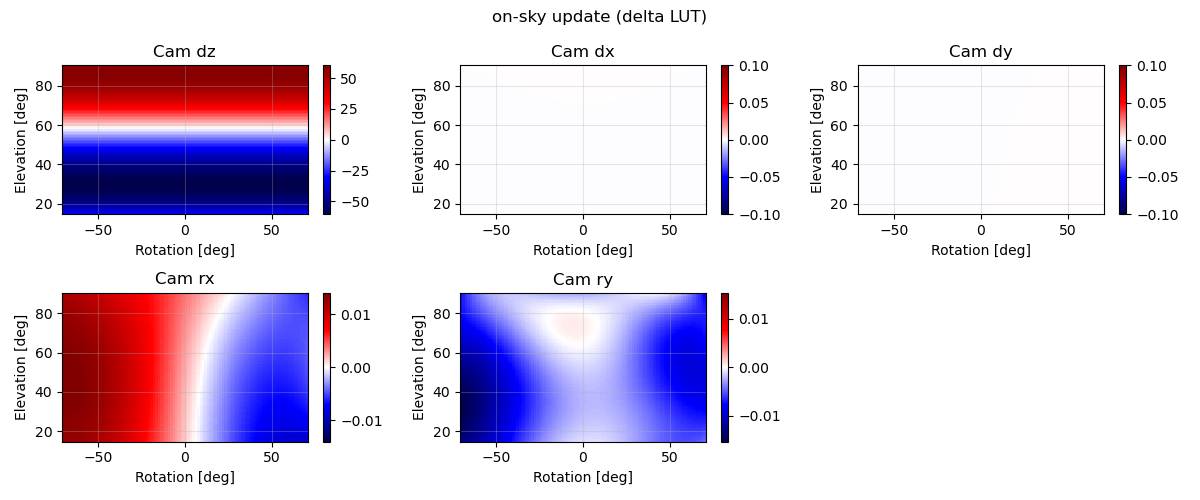

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyval2d

home_path = os.getenv("HOME")
# loading laser derived LUT
lut_path_update = os.path.join(
    home_path,
    "notebooks/lsst-ts/ts_config_mttcs/MTHexapod/v6/laser_rotation_elevation_v19.yaml",
)

with open(lut_path_update, "r") as yaml_file:
    lut_data = yaml.safe_load(yaml_file)
coeffs = lut_data["camera_config"]["elevation_rotation_coeffs"]


poly_degs = [
    (3, 0), # dz
    (2, 2), # dx not really used
    (2, 2), # dy not really used
    (2, 3), # drx
    (4, 4) # dry
]

indices = [2, 0, 1, 3, 4]
plt.figure(figsize=(12, 5))
for i, dof in enumerate(use_dof):
    ax = plt.subplot(2, 3, i + 1)

    # Prepare data
    rot = np.asarray(rotations_array[:])
    el = np.asarray(elevations_array[:])
    val = -np.asarray(states_array[:, i])

    # --- Fit 2D polynomial ---
    deg = 3
    coeffs_fit = fit_poly2d(el, rot, val, deg_x=poly_degs[i][0], deg_y=poly_degs[i][1])

    # --- Evaluate on grid ---
    rot_grid = np.linspace(-70, 70, 100)
    el_grid = np.linspace(15, 90, 100)
    ROT, EL = np.meshgrid(rot_grid, el_grid)
    
    Z_fit = polyval2d(EL, ROT, coeffs_fit)
    Z = polyval2d(EL, ROT, coeffs[indices[i]])

    padded_zemax, padded_laser = pad_coeffs(np.array(coeffs_fit), np.array(coeffs[indices[i]]))

    Z = polyval2d(EL, ROT, padded_laser)
    #Z_fit = polyval2d(EL, ROT, padded_zemax)
    Z_total = polyval2d(EL, ROT, padded_zemax + padded_laser)

    print(f"{labels[i]}: {-padded_zemax + padded_laser}")
    print('--------------------')
    

    # --- Symmetric color limits ---
    data_to_plot = Z_fit
    abs_max = np.nanmax(np.abs(data_to_plot))
    if i < 3:
        abs_max = max(abs_max, 0.1)
    vmin, vmax = -abs_max, abs_max

    # --- Plot fitted surface ---
    surf = ax.pcolormesh(
        ROT, EL, data_to_plot,
        shading="auto", cmap="seismic",
        vmin=vmin, vmax=vmax
    )
    plt.colorbar(surf, ax=ax)

    ax.set_title(labels[i])
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")
    ax.grid(True, alpha=0.3)

plt.suptitle('on-sky update (delta LUT)')
plt.tight_layout()
plt.show()


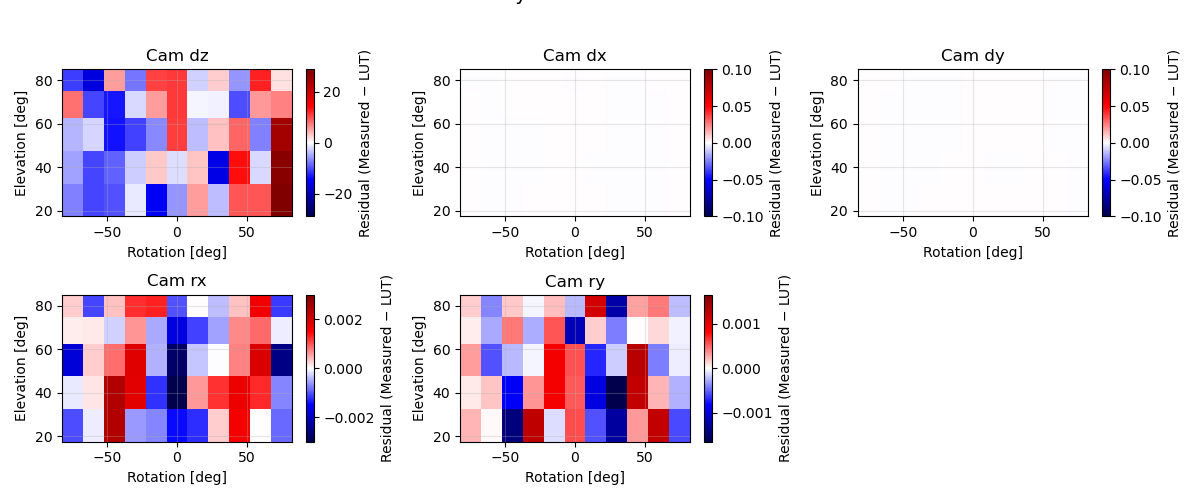

In [145]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyval2d

# --- Polynomial degrees and indices ---
indices = [2, 0, 1, 3, 4]

plt.figure(figsize=(12, 5))
for i, dof in enumerate(use_dof):
    ax = plt.subplot(2, 3, i + 1)

    # --- Actual measured data ---
    rot = np.asarray(rotations_array)
    el = np.asarray(elevations_array)
    measured_val = -np.asarray(states_array[:, i])

    # --- Fit 2D polynomial ---
    coeffs_fit = fit_poly2d(el, rot, measured_val, deg_x=poly_degs[i][0], deg_y=poly_degs[i][1])
    predicted_val = polyval2d(el, rot, coeffs_fit)
    
    # --- Compute residuals (measured - predicted) ---
    residuals = measured_val - predicted_val

    # --- Pivot for plotting ---
    df_plot = pd.DataFrame({
        "rot": rot,
        "el": el,
        "resid": residuals
    })
    grid = df_plot.pivot(index="el", columns="rot", values="resid")

    # --- Symmetric color scale ---
    abs_max = np.nanmax(np.abs(grid.values))
    if i < 3:
        abs_max = max(abs_max, 0.1)
    vmin, vmax = -abs_max, abs_max

    # --- Plot residuals (on-sky − LUT) ---
    surf = ax.pcolormesh(
        grid.columns, grid.index, grid.values,
        shading="auto", cmap="seismic",
        vmin=vmin, vmax=vmax
    )
    plt.colorbar(surf, ax=ax, label="Residual (Measured − LUT)")

    ax.set_title(labels[i])
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")
    ax.grid(True, alpha=0.3)

plt.suptitle("Residuals: On-sky Measurements − LUT Prediction", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
import numpy as np
from numpy.polynomial.polynomial import polyvander2d
from numpy.polynomial.polynomial import polyfit, polyval2d, polyval
from copy import deepcopy
from functools import partial
import yaml

def fit_poly2d(x, y, z, deg_rot=3, deg_el=3):
    """
    Fit a 2D polynomial z(x, y) of total degree 'deg' using NumPy's polyvander2d.
    Returns a 2D array of coefficients usable by polyval2d.
    """
    # Generate Vandermonde matrix
    V = polyvander2d(x, y, [deg_rot, deg_el])

    # Solve least-squares fit
    coeffs, *_ = np.linalg.lstsq(V, z, rcond=None)

    # Reshape to 2D coefficient matrix
    coeffs = coeffs.reshape((deg_rot + 1, deg_el+ 1))
    return coeffs

def pad_coeffs(c1, c2):
    """Pad two 2D coefficient arrays to the same shape with zeros."""
    max_rows = max(c1.shape[0], c2.shape[0])
    max_cols = max(c1.shape[1], c2.shape[1])
    padded_c1 = np.zeros((max_rows, max_cols))
    padded_c2 = np.zeros((max_rows, max_cols))
    padded_c1[:c1.shape[0], :c1.shape[1]] = c1
    padded_c2[:c2.shape[0], :c2.shape[1]] = c2
    return padded_c1, padded_c2

[73.89036905 64.45382438 51.99350824 69.24824173 74.79498392 69.06196446
 77.31623971 84.45305942 64.55924065 73.24798672 81.96228042 45.39828632
 49.36767759 31.85946239 42.91428292 39.2717564  28.7383881  41.98340479
 53.92248383 40.11475774 35.94810035 44.07344715 -3.4072795   7.20917908
 -0.49539814  4.92788716  3.46544581  0.62208592 -3.74396847  2.939198
  7.87807211 -2.9865402   4.78087886]
[-2.51286639e-08  2.05397858e-08 -2.22996004e-08  8.43531098e-09
  2.45985425e-08  2.07949501e-08  3.26430274e-08  3.77835500e-08
 -1.26863198e-08 -1.71997453e-09 -2.40208665e-08 -6.40068889e-08
  1.54050097e-08 -3.25363880e-08 -4.48874984e-09  1.62636495e-08
 -1.00908006e-08  7.49923749e-09  2.33042335e-08 -4.39184595e-08
 -1.38659177e-08 -4.84236867e-08 -7.52343106e-08  3.64210906e-10
 -5.62911180e-08 -3.20589319e-08 -1.79887714e-09 -4.52610582e-08
 -1.80018830e-08  1.16787237e-08 -5.45181867e-08 -4.70216637e-08
 -7.19064414e-08]
[-8.60587057e-08 -7.95681432e-08 -8.51307573e-08  4.66883971e

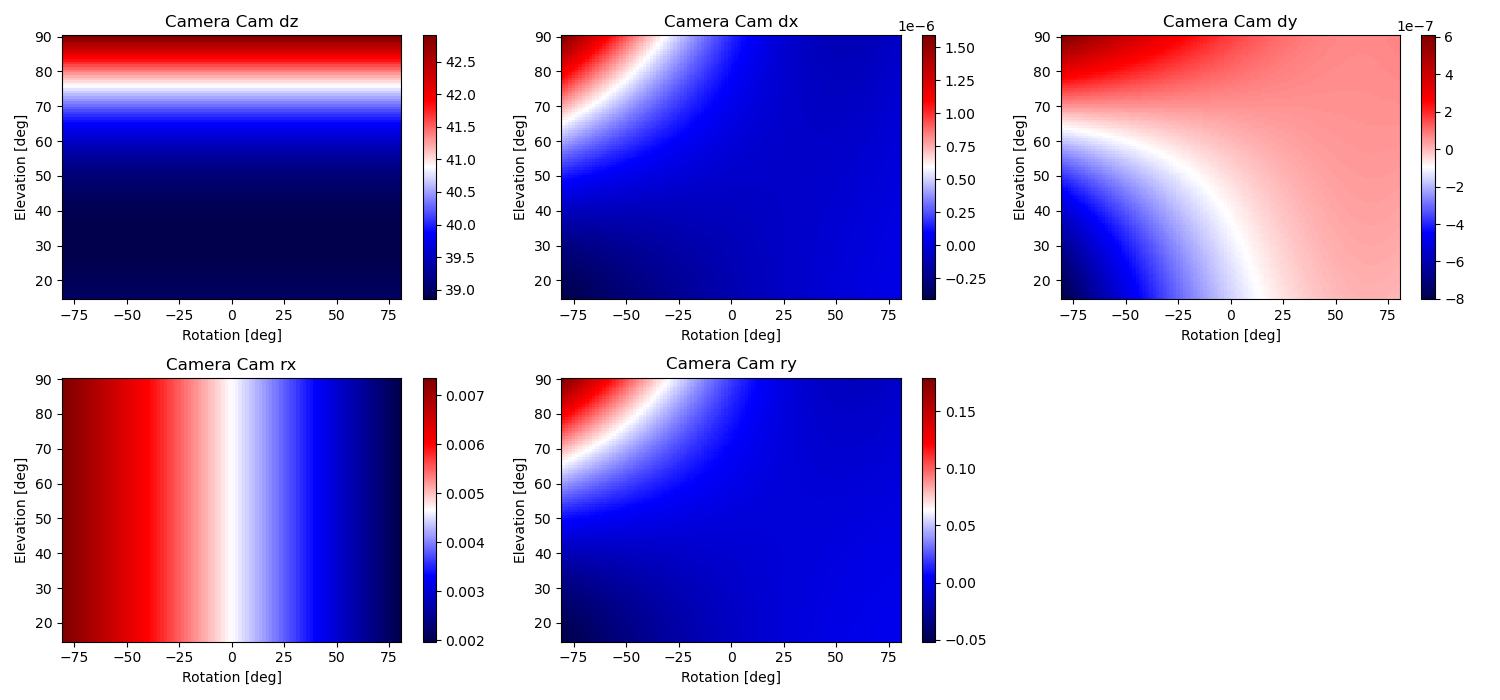

In [56]:


x = rotations_array
y = elevations_array
el = np.linspace(15, 90, 100)  # elevation in degrees
rot = np.linspace(-80, 80, 100)  # rotation in degrees
EL, ROT = np.meshgrid(el, rot)

# Plot each axis
plt.figure(figsize=(15, 7))
indices = [2, 0, 1, 3, 4]
poly_degs = [
    (3, 0),
    (2, 2),
    (2, 2),
    (0, 1),
    (2, 2)
]
for i, dof in enumerate(use_dof):
    z = -states_array[:, i]

    print(z)

    coeffs_fit = fit_poly2d(x, y, z, poly_degs[i][0], poly_degs[i][1])
    Z_fit = polyval2d(EL, ROT, coeffs_fit)
    Z = polyval2d(EL, ROT, coeffs[indices[i]])

    padded_zemax, padded_laser = pad_coeffs(np.array(coeffs_fit), np.array(coeffs[indices[i]]))

    Z = polyval2d(EL, ROT, padded_laser)
    Z_total = polyval2d(EL, ROT, padded_zemax + padded_laser)

    #print(f"{labels[i]}: {padded_zemax + padded_laser}")
    #print('--------------------')
    
    ax = plt.subplot(2, 3, i + 1)
    surf = ax.pcolormesh(ROT, EL, Z_fit, shading="auto", cmap="seismic")
    plt.colorbar(surf, ax=ax)
    ax.set_title(f"Camera {labels[i]}")
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")


plt.tight_layout()